## Importing Librarires

In [2]:
import pandas as pd
from pathlib import Path

## Loading CSV Files into Data Frames

In [3]:
base_path = Path.cwd()
orders_file = base_path /'order_details.csv'
menu_file = base_path /'menu_items.csv'

In [4]:
df_orders = pd.read_csv(orders_file, parse_dates=['order_date'])
df_menu = pd.read_csv(menu_file)

C:\Users\Nadeem.Salam\AppData\Local\Temp\ipykernel_30356\3438666850.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_orders = pd.read_csv(orders_file, parse_dates=['order_date'])


In [5]:
df_orders.head(5)

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,2023-01-01,11:38:36 AM,109.0
1,2,2,2023-01-01,11:57:40 AM,108.0
2,3,2,2023-01-01,11:57:40 AM,124.0
3,4,2,2023-01-01,11:57:40 AM,117.0
4,5,2,2023-01-01,11:57:40 AM,129.0


In [6]:
df_orders.tail(5)

,order_details_id,order_id,order_date,order_time,item_id
12229,12230,5369,2023-03-31,10:05:04 PM,109.0
12230,12231,5369,2023-03-31,10:05:04 PM,129.0
12231,12232,5369,2023-03-31,10:05:04 PM,120.0
12232,12233,5369,2023-03-31,10:05:04 PM,122.0
12233,12234,5370,2023-03-31,10:15:48 PM,122.0


In [7]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  datetime64[ns]
 3   order_time        12234 non-null  object        
 4   item_id           12097 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 478.0+ KB


In [8]:
df_orders.dropna(axis=0, how='any', inplace=True)

In [9]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12097 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12097 non-null  int64         
 1   order_id          12097 non-null  int64         
 2   order_date        12097 non-null  datetime64[ns]
 3   order_time        12097 non-null  object        
 4   item_id           12097 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 567.0+ KB


In [10]:
df_menu.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [11]:
df_menu.tail()

,menu_item_id,item_name,category,price
27,128,Cheese Lasagna,Italian,15.50
28,129,Mushroom Ravioli,Italian,15.50
29,130,Shrimp Scampi,Italian,19.95
30,131,Chicken Parmesan,Italian,17.95
31,132,Eggplant Parmesan,Italian,16.95


In [12]:
df_menu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   menu_item_id  32 non-null     int64  
 1   item_name     32 non-null     object 
 2   category      32 non-null     object 
 3   price         32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


## Joining the Data

In [16]:
#order_items_df = df_orders.merge(df_menu , how = "left", left_on = "item_id", right_on = "menu_item_id").drop(columns = ["menu_item_id"])
order_items_df = df_orders.merge(df_menu , how = "left", left_on = "item_id", right_on = "menu_item_id").drop("menu_item_id", axis=1)
order_items_df.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price
0,1,1,2023-01-01,11:38:36 AM,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,11:57:40 AM,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,11:57:40 AM,124.0,Spaghetti,Italian,14.50
3,4,2,2023-01-01,11:57:40 AM,117.0,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,11:57:40 AM,129.0,Mushroom Ravioli,Italian,15.50


In [21]:
order_items_df["sales_tax"] = (order_items_df["price"] * 0.08 ).round(2)
order_items_df["total_revenue"] = order_items_df.price + order_items_df.sales_tax
order_items_df.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,sales_tax,total_revenue
0,1,1,2023-01-01,11:38:36 AM,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39
1,2,2,2023-01-01,11:57:40 AM,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66
2,3,2,2023-01-01,11:57:40 AM,124.0,Spaghetti,Italian,14.50,1.16,15.66
3,4,2,2023-01-01,11:57:40 AM,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99
4,5,2,2023-01-01,11:57:40 AM,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74


In [46]:
order_items_df['order_timestamp'] = pd.to_datetime(order_items_df['order_date']) + pd.to_timedelta(order_items_df['order_time'].astype(str))
order_items_df.drop(columns=['order_date', 'order_time'], inplace=True)
order_items_df.head()


,order_details_id,order_id,item_id,item_name,category,price,sales_tax,total_revenue,order_timestamp
0,1,1,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39,2023-01-01 11:38:36
1,2,2,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66,2023-01-01 11:57:40
2,3,2,124.0,Spaghetti,Italian,14.50,1.16,15.66,2023-01-01 11:57:40
3,4,2,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99,2023-01-01 11:57:40
4,5,2,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74,2023-01-01 11:57:40


In [47]:
order_items_df.describe()

,order_details_id,order_id,item_id,price,sales_tax,total_revenue,order_timestamp
count,12097.000000,12097.000000,12097.000000,12097.000000,12097.000000,12097.000000,12097
mean,6118.950897,2692.569149,115.202282,13.161767,1.055128,14.216895,2023-02-14 17:56:03.990080512
min,1.000000,1.000000,101.000000,5.000000,0.400000,5.400000,2023-01-01 01:00:15
25%,3064.000000,1353.000000,107.000000,10.500000,0.840000,11.340000,2023-01-23 06:45:57
50%,6119.000000,2711.000000,114.000000,13.950000,1.120000,15.070000,2023-02-14 09:08:21
75%,9175.000000,4020.000000,123.000000,16.500000,1.320000,17.820000,2023-03-09 04:50:50
max,12234.000000,5370.000000,132.000000,19.950000,1.600000,21.550000,2023-03-31 12:59:45
std,3531.337208,1545.826452,9.387580,3.986392,0.320078,4.306466,NaN


### Analyzing Best & Worst Selling Items

In [36]:
(
    order_items_df
    .groupby("item_name")
    .agg({"total_revenue": "sum"})
    .sort_values("total_revenue")
 )

,total_revenue
item_name,
Chicken Tacos,1587.93
Potstickers,1992.60
Chips & Guacamole,2303.64
Hot Dog,2498.04
Cheese Quesadillas,2642.22
Veggie Burger,2698.92
Steak Tacos,3224.98
Edamame,3348.00
Cheese Lasagna,3465.18


<Axes: title={'center': 'Total Revenue by Menu Item'}, ylabel='item_name'>

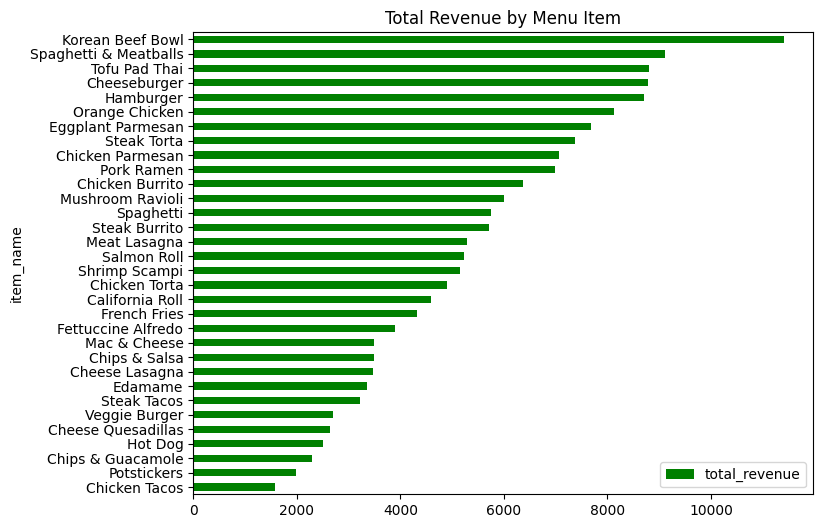

In [38]:
(
    order_items_df
    .groupby("item_name")
    .agg({"total_revenue": "sum"})
    .sort_values("total_revenue")
    .plot.barh(figsize=(8, 6), color="green",title="Total Revenue by Menu Item")
 )

### Filtering the result of a specific category

<Axes: title={'center': 'Total Revenue by Menu Item'}, ylabel='item_name'>

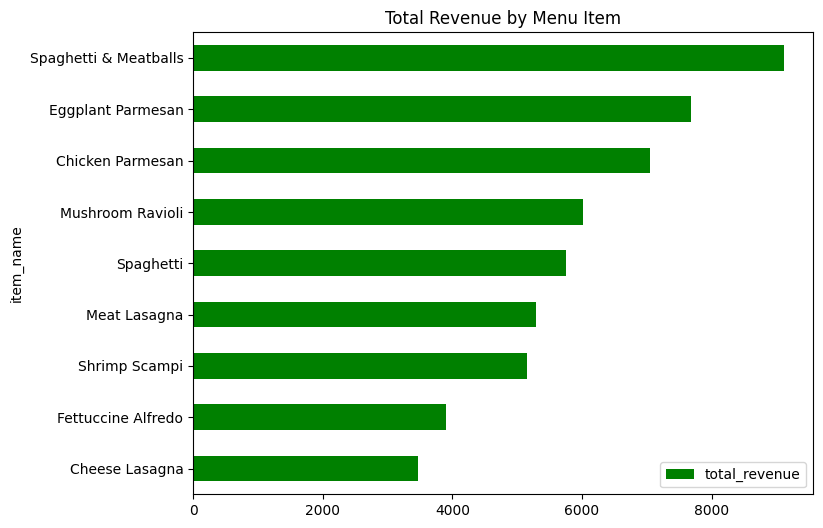

In [43]:
(
    order_items_df
    .query("category == 'Italian'")
    .groupby("item_name")
    .agg({"total_revenue": "sum"})
    .sort_values("total_revenue")
    .plot.barh(figsize=(8, 6), color="green",title="Total Revenue by Menu Item")
 )

## Time Based Analysis

### Analyzing Busiest Times

In [48]:
order_items_df.set_index("order_timestamp")

,order_details_id,order_id,item_id,item_name,category,price,sales_tax,total_revenue
order_timestamp,,,,,,,,
2023-01-01 11:38:36,1,1,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39
2023-01-01 11:57:40,2,2,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66
2023-01-01 11:57:40,3,2,124.0,Spaghetti,Italian,14.50,1.16,15.66
2023-01-01 11:57:40,4,2,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99
2023-01-01 11:57:40,5,2,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74
...,...,...,...,...,...,...,...,...
2023-03-31 10:05:04,12230,5369,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39
2023-03-31 10:05:04,12231,5369,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74
2023-03-31 10:05:04,12232,5369,120.0,Steak Torta,Mexican,13.95,1.12,15.07


<Axes: title={'center': 'Total Revenue by Day'}, xlabel='order_timestamp'>

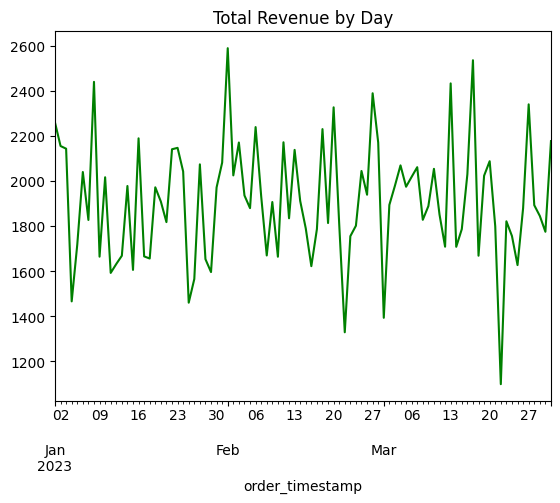

In [55]:
# order_items_df.set_index("order_timestamp").resample("D").agg({"total_revenue": "sum"}).plot(color="green", title="Total Revenue by Day")
order_items_df.set_index("order_timestamp").resample("D")["total_revenue"].sum().plot(color="green", title="Total Revenue by Day")
#order_items_df.set_index("order_timestamp").resample("M")["total_revenue"].sum().plot(color="green", title="Total Revenue by Month")

In [56]:
order_items_df["dayofweek"] = order_items_df["order_timestamp"].dt.day_of_week
order_items_df["hour"] = order_items_df["order_timestamp"].dt.hour
order_items_df.head()

,order_details_id,order_id,item_id,item_name,category,price,sales_tax,total_revenue,order_timestamp,dayofweek,hour
0,1,1,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39,2023-01-01 11:38:36,6,11
1,2,2,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66,2023-01-01 11:57:40,6,11
2,3,2,124.0,Spaghetti,Italian,14.50,1.16,15.66,2023-01-01 11:57:40,6,11
3,4,2,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99,2023-01-01 11:57:40,6,11
4,5,2,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74,2023-01-01 11:57:40,6,11


In [ ]:
order_items_df.pivot_table(index="hour",columns="dayofweek", values="total_revenue", aggfunc="sum")

dayofweek,0,1,2,3,4,5,6
hour,,,,,,,
1,3485.13,2107.75,2164.73,3141.56,4014.76,2856.21,4524.79
2,1564.97,1903.19,2010.10,1837.02,2088.30,1991.64,2231.88
3,1341.46,1783.21,1705.90,1388.44,1458.24,1165.96,1746.69
4,1847.87,2309.06,2668.19,2407.43,2212.55,1597.46,1768.29
5,2961.90,2494.85,2552.63,2920.02,2849.34,2521.67,3001.61
6,2991.99,3015.99,2342.69,2471.70,2119.62,2728.58,2542.57
7,2946.77,3014.23,1756.36,1979.72,2030.82,1772.95,1807.91
8,2437.67,2603.39,1599.18,983.55,2026.15,1517.79,1447.15
9,2019.78,1850.71,1037.65,815.43,991.65,1038.23,622.50


<Axes: xlabel='dayofweek', ylabel='hour'>

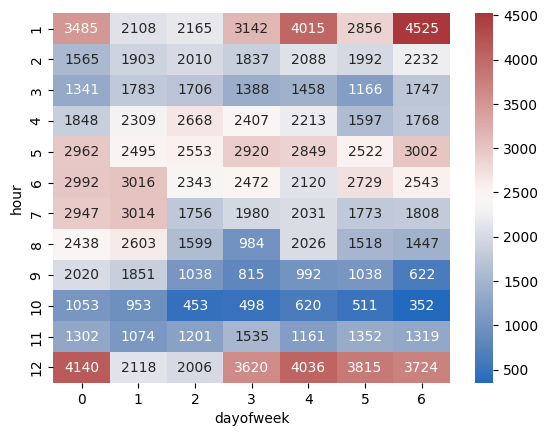

In [71]:
import seaborn as sns
sns.heatmap(
order_items_df.pivot_table(index="hour",columns="dayofweek", values="total_revenue", aggfunc="sum"),
annot=True, fmt=".0f", cmap="vlag"
)